# Logistics Company Analytics Notebook
**IBM Watsonx | Supabase Edge Function API**

---
Run each cell one at a time using **Shift + Enter**. Start from Cell 1 and go downward.

| Section | Topic |
|---------|-------|
| 1 | Setup & Connection Test |
| 2 | Driver Performance |
| 3 | Route Profitability |
| 4 | Fleet Utilization |
| 5 | Fuel Efficiency |
| 6 | Customer Revenue |
| 7 | Safety Incidents |

In [1]:
# CELL 1 - Install and import libraries
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn", "requests"],
               capture_output=True)

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.figsize"] = (14, 5)
sns.set_theme(style="whitegrid")

# API endpoint - connects via HTTPS (no port issues)
API = "https://YOUR_PROJECT_REF.supabase.co/functions/v1/analytics"

def fetch(query_name):
    r = requests.get(API, params={"query": query_name}, timeout=30)
    r.raise_for_status()
    rows = r.json().get("data") or []
    return pd.DataFrame(rows)

print("Setup complete. Testing connection...")
df_test = fetch("table_counts")
print("Connected successfully via HTTPS!")
print()
print(f"{'Table':<35} {'Rows':>10}")
print("-" * 47)
for _, row in df_test.iterrows():
    n = int(row['n'])
    ok = "OK" if n > 0 else "EMPTY"
    print(f"  {row['tbl']:<33} {n:>10,}  {ok}")

Setup complete. Testing connection...
Connected successfully via HTTPS!

Table                                     Rows
-----------------------------------------------
  drivers                                  150  OK
  trucks                                   120  OK
  trailers                                 180  OK
  customers                                200  OK
  facilities                                50  OK
  routes                                    58  OK
  loads                                 85,410  OK
  trips                                 85,410  OK
  fuel_purchases                       196,442  OK
  maintenance_records                    2,920  OK
  delivery_events                      170,820  OK
  safety_incidents                         170  OK
  driver_monthly_metrics                 4,464  OK
  truck_utilization_metrics              3,312  OK


---
## Section 2 - Driver Performance

In [2]:
# CELL 2 - Driver Scorecard (Top 20 by Revenue)
df_drivers = fetch("driver_scorecard")
for col in ["total_miles","total_revenue","avg_mpg","revenue_per_mile","on_time_pct"]:
    df_drivers[col] = pd.to_numeric(df_drivers[col], errors="coerce")
print("Top 20 Drivers by Revenue")
df_drivers

Top 20 Drivers by Revenue


,driver_name,home_terminal,total_trips,total_miles,total_revenue,avg_mpg,revenue_per_mile,on_time_pct
0,Linda Davis,Atlanta,723,1074677,"2,311,844.30",6.50,2.15,43.30
1,Joseph Jones,Minneapolis,735,1073445,"2,311,327.90",6.52,2.15,48.20
2,Barbara Gonzalez,Los Angeles,729,1064844,"2,305,056.60",6.52,2.16,45.30
3,Thomas Gonzalez,Kansas City,712,1042631,"2,278,574.88",6.50,2.19,45.10
4,Robert Jackson,Seattle,749,1060268,"2,275,654.76",6.47,2.15,45.30
5,Thomas Gonzalez,Portland,702,1047108,"2,272,317.62",6.50,2.17,42.00
6,Linda Jones,New York,721,1059718,"2,269,105.67",6.50,2.14,44.80
7,Richard Garcia,Oklahoma City,705,1039157,"2,256,066.92",6.49,2.17,45.70
8,Linda Wilson,Nashville,703,1034233,"2,229,521.23",6.51,2.16,45.90
9,William Anderson,Charlotte,725,1029613,"2,214,003.33",6.51,2.15,42.60


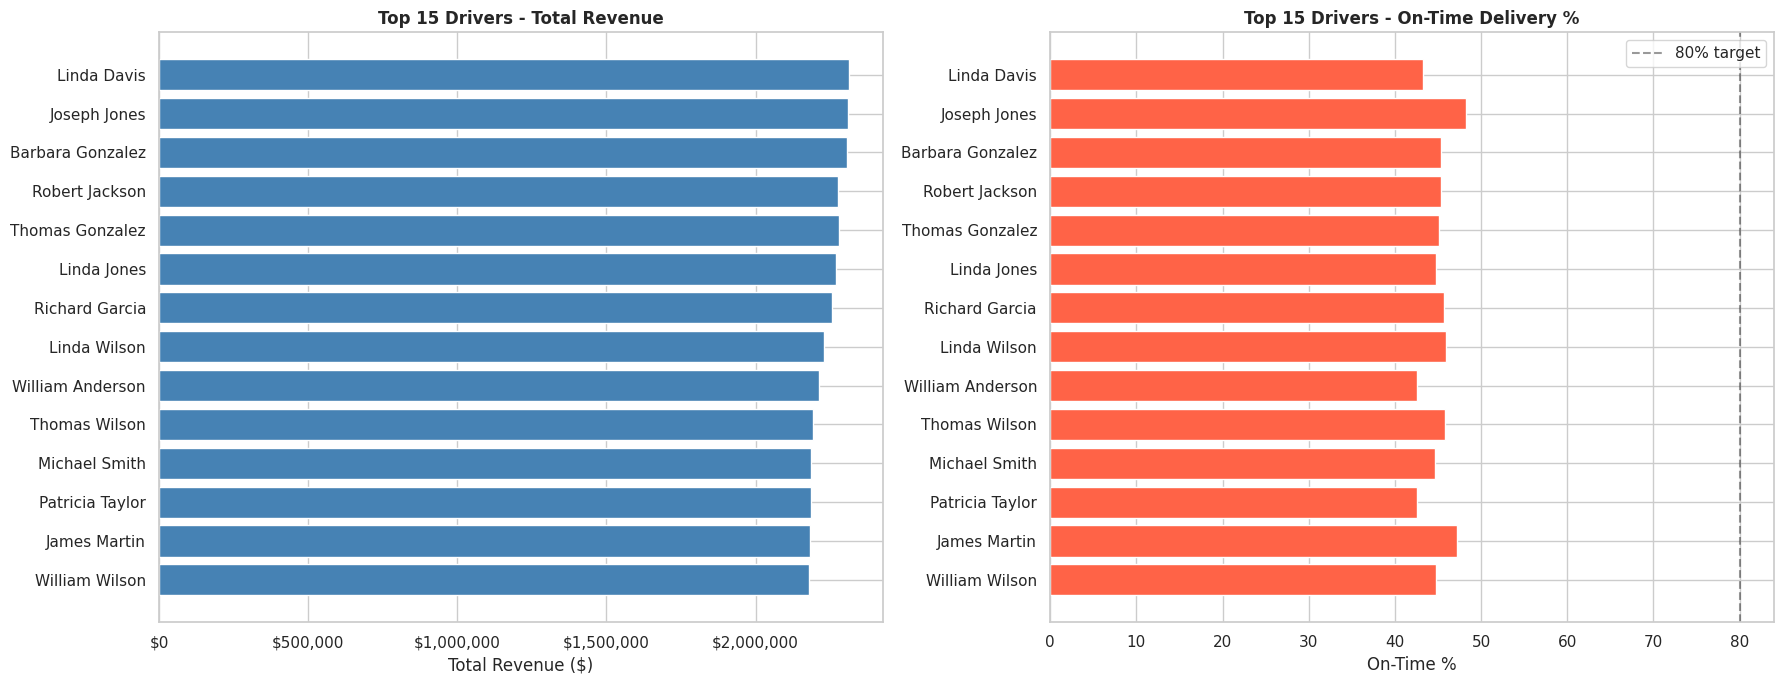

Green=80%+  Orange=60-79%  Red=below 60%


In [3]:
# CELL 3 - Chart: Revenue and On-Time % for Top 15 Drivers
top15 = df_drivers.head(15).sort_values("total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(top15["driver_name"], top15["total_revenue"], color="steelblue")
axes[0].set_title("Top 15 Drivers - Total Revenue", fontweight="bold")
axes[0].set_xlabel("Total Revenue ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

colors = ["seagreen" if x>=80 else "orange" if x>=60 else "tomato" for x in top15["on_time_pct"]]
axes[1].barh(top15["driver_name"], top15["on_time_pct"], color=colors)
axes[1].axvline(x=80, color="black", linestyle="--", alpha=0.4, label="80% target")
axes[1].set_title("Top 15 Drivers - On-Time Delivery %", fontweight="bold")
axes[1].set_xlabel("On-Time %")
axes[1].legend()
plt.tight_layout()
plt.show()
print("Green=80%+  Orange=60-79%  Red=below 60%")

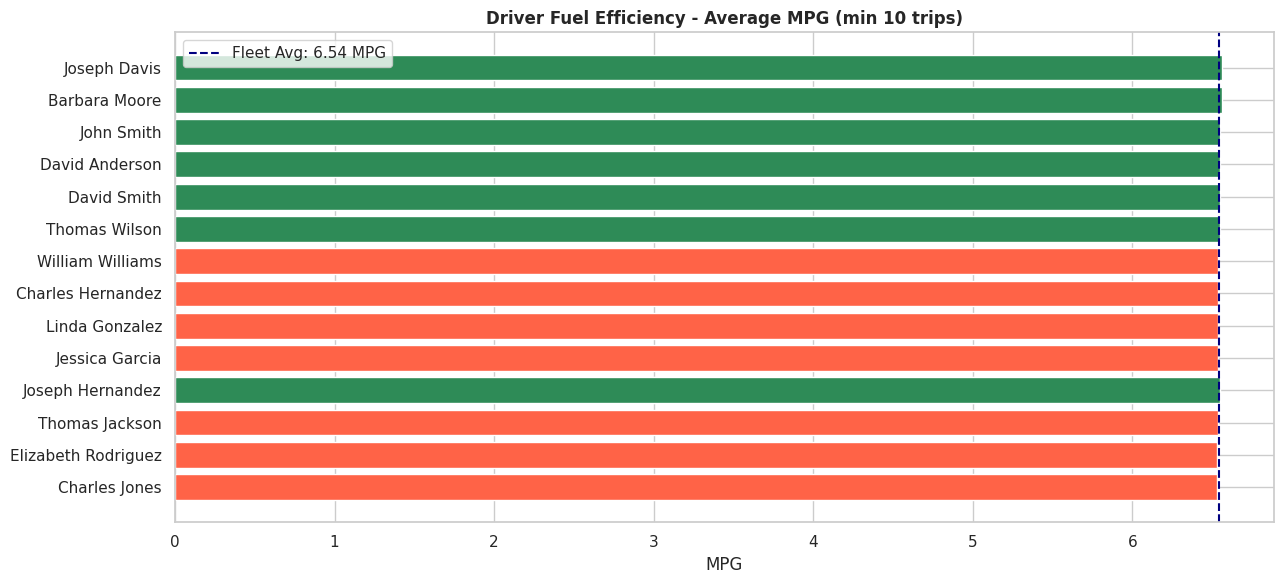

Fleet average MPG: 6.54  Green=above average  Red=below average


In [4]:
# CELL 4 - Driver Fuel Efficiency (MPG)
df_mpg = fetch("driver_mpg")
df_mpg["avg_mpg"] = pd.to_numeric(df_mpg["avg_mpg"], errors="coerce")
fleet_avg = float(df_mpg["avg_mpg"].mean())
df_s = df_mpg.sort_values("avg_mpg", ascending=True)
colors = ["seagreen" if x>=fleet_avg else "tomato" for x in df_s["avg_mpg"]]

plt.figure(figsize=(13, 6))
plt.barh(df_s["driver_name"], df_s["avg_mpg"], color=colors)
plt.axvline(x=fleet_avg, color="navy", linestyle="--", label=f"Fleet Avg: {fleet_avg:.2f} MPG")
plt.title("Driver Fuel Efficiency - Average MPG (min 10 trips)", fontweight="bold")
plt.xlabel("MPG")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Fleet average MPG: {fleet_avg:.2f}  Green=above average  Red=below average")

---
## Section 3 - Route Profitability

In [5]:
# CELL 5 - Top 20 Routes by Revenue
df_routes = fetch("route_profitability")
for col in ["total_loads","total_revenue","avg_per_load","rate_per_mile"]:
    df_routes[col] = pd.to_numeric(df_routes[col], errors="coerce")
print("Top 20 Routes by Revenue")
df_routes

Top 20 Routes by Revenue


,lane,total_loads,total_revenue,avg_per_load,rate_per_mile
0,"Philadelphia, PA to Seattle, WA",1465,"10,069,054.22","6,873.07",2.52
1,"Charlotte, NC to Portland, OR",1410,"9,979,091.72","7,077.37",2.69
2,"Phoenix, AZ to Philadelphia, PA",1507,"9,757,537.38","6,474.81",2.71
3,"Columbus, OH to Portland, OR",1525,"9,586,536.90","6,286.25",2.70
4,"Seattle, WA to Charlotte, NC",1467,"9,516,077.71","6,486.76",2.47
5,"Columbus, OH to Los Angeles, CA",1534,"9,501,202.04","6,193.74",2.73
6,"Charlotte, NC to Seattle, WA",1447,"9,070,885.01","6,268.75",2.39
7,"Seattle, WA to Indianapolis, IN",1445,"7,681,556.33","5,315.96",2.48
8,"Chicago, IL to Los Angeles, CA",1496,"7,621,380.80","5,094.51",2.54
9,"Houston, TX to Portland, OR",1473,"7,595,328.46","5,156.37",2.45


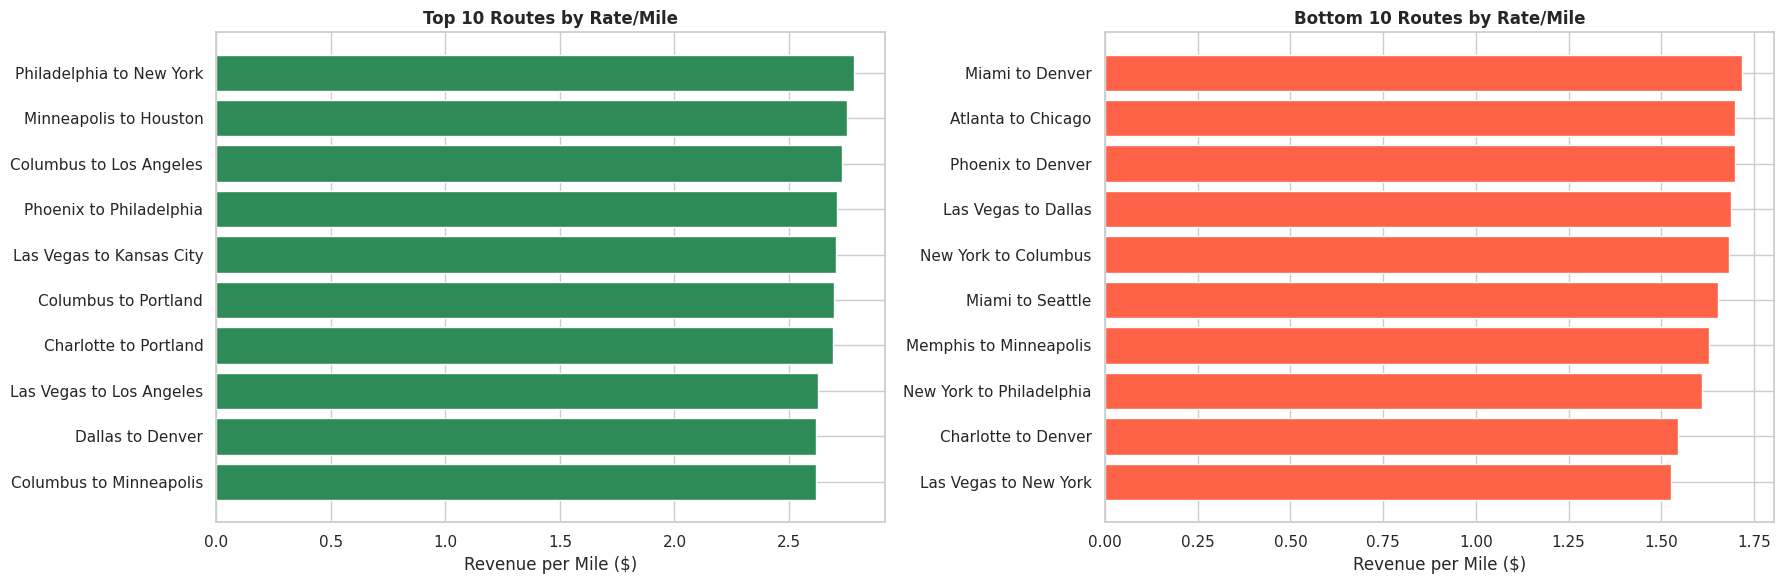

Consider renegotiating rates on bottom 10 lanes


In [6]:
# CELL 6 - Best vs Worst Routes Chart
df_all = fetch("route_rate_per_mile")
df_all["rate_per_mile"] = pd.to_numeric(df_all["rate_per_mile"], errors="coerce")
top10    = df_all.head(10).sort_values("rate_per_mile", ascending=True)
bottom10 = df_all.tail(10).sort_values("rate_per_mile", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].barh(top10["lane"], top10["rate_per_mile"], color="seagreen")
axes[0].set_title("Top 10 Routes by Rate/Mile", fontweight="bold")
axes[0].set_xlabel("Revenue per Mile ($)")
axes[1].barh(bottom10["lane"], bottom10["rate_per_mile"], color="tomato")
axes[1].set_title("Bottom 10 Routes by Rate/Mile", fontweight="bold")
axes[1].set_xlabel("Revenue per Mile ($)")
plt.tight_layout()
plt.show()
print("Consider renegotiating rates on bottom 10 lanes")

---
## Section 4 - Fleet Utilization

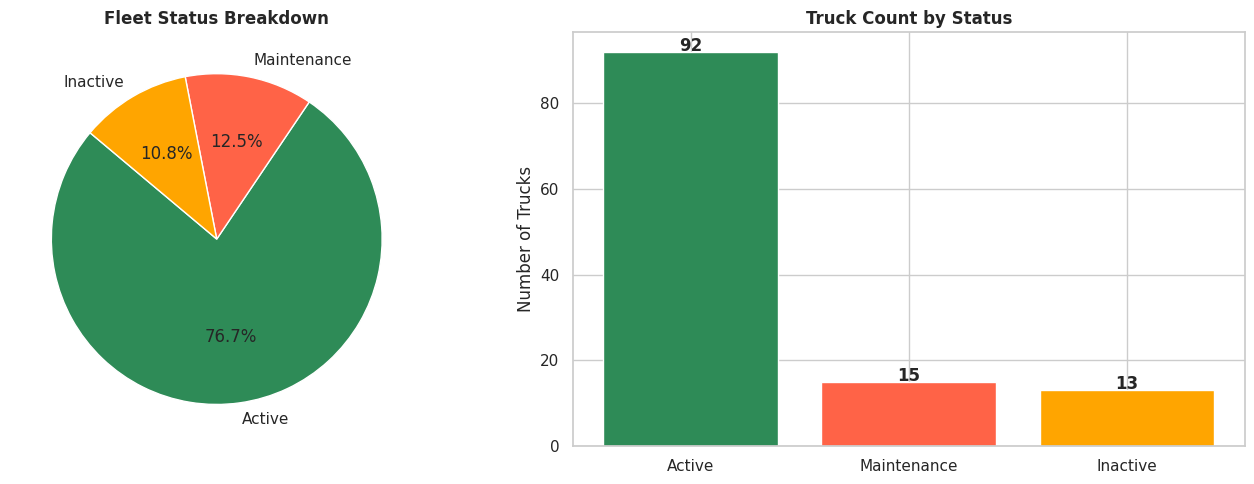

     status  truck_count   pct
     Active           92 76.70
Maintenance           15 12.50
   Inactive           13 10.80


In [7]:
# CELL 7 - Fleet Status Breakdown
df_status = fetch("fleet_status")
df_status["truck_count"] = pd.to_numeric(df_status["truck_count"], errors="coerce")

palette = ["seagreen","tomato","orange","steelblue","gray"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(df_status["truck_count"], labels=df_status["status"],
            autopct="%1.1f%%", colors=palette[:len(df_status)], startangle=140)
axes[0].set_title("Fleet Status Breakdown", fontweight="bold")
axes[1].bar(df_status["status"], df_status["truck_count"], color=palette[:len(df_status)])
axes[1].set_title("Truck Count by Status", fontweight="bold")
axes[1].set_ylabel("Number of Trucks")
for i,v in enumerate(df_status["truck_count"]):
    axes[1].text(i, v+0.2, str(int(v)), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()
print(df_status.to_string(index=False))

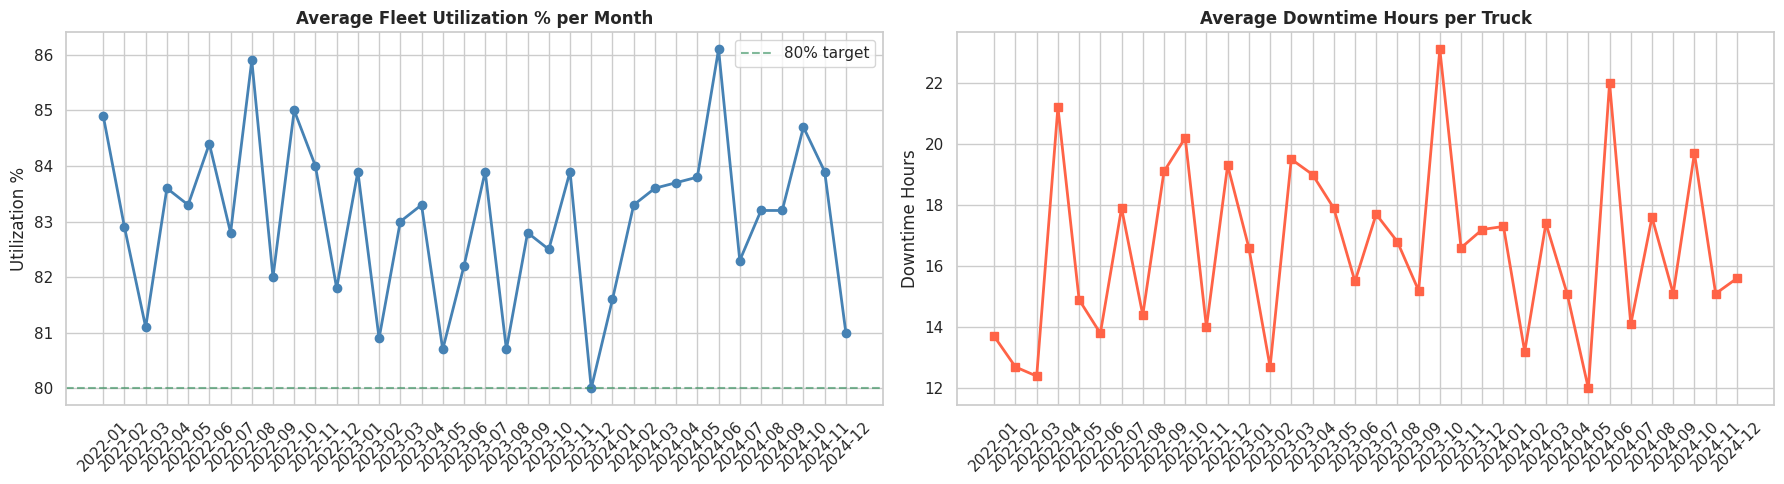

In [8]:
# CELL 8 - Monthly Fleet Utilization and Downtime
df_util = fetch("fleet_utilization")
for col in ["avg_util_pct","avg_downtime_hours"]:
    df_util[col] = pd.to_numeric(df_util[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(df_util["month"], df_util["avg_util_pct"], marker="o", color="steelblue", linewidth=2)
axes[0].axhline(y=80, color="seagreen", linestyle="--", alpha=0.6, label="80% target")
axes[0].set_title("Average Fleet Utilization % per Month", fontweight="bold")
axes[0].set_ylabel("Utilization %")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[1].plot(df_util["month"], df_util["avg_downtime_hours"], marker="s", color="tomato", linewidth=2)
axes[1].set_title("Average Downtime Hours per Truck", fontweight="bold")
axes[1].set_ylabel("Downtime Hours")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## Section 5 - Fuel Efficiency

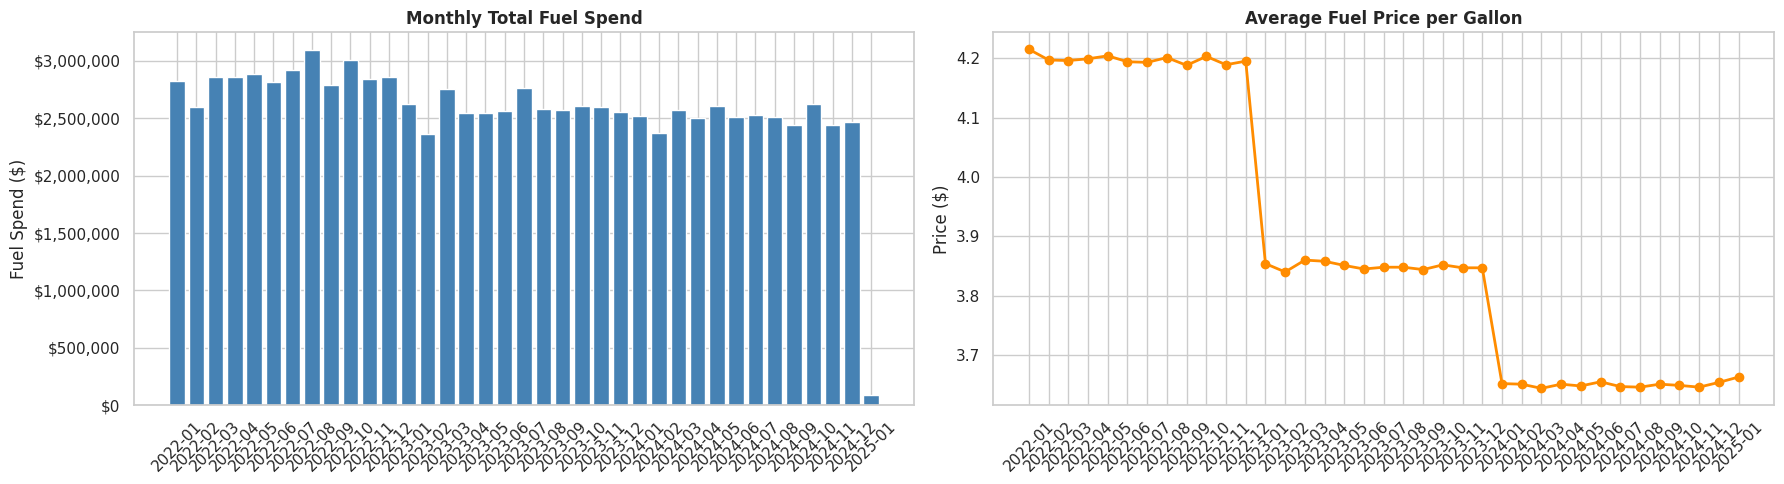

Total fuel spend: $95,592,992.04


In [9]:
# CELL 9 - Monthly Fuel Spend and Price Trend
df_fuel = fetch("fuel_monthly")
for col in ["total_fuel_spend","avg_price_per_gallon","total_gallons"]:
    df_fuel[col] = pd.to_numeric(df_fuel[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].bar(df_fuel["month"], df_fuel["total_fuel_spend"], color="steelblue")
axes[0].set_title("Monthly Total Fuel Spend", fontweight="bold")
axes[0].set_ylabel("Fuel Spend ($)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[1].plot(df_fuel["month"], df_fuel["avg_price_per_gallon"],
             marker="o", color="darkorange", linewidth=2)
axes[1].set_title("Average Fuel Price per Gallon", fontweight="bold")
axes[1].set_ylabel("Price ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print(f"Total fuel spend: ${float(df_fuel['total_fuel_spend'].sum()):,.2f}")

---
## Section 6 - Customer Revenue and Service Levels

Top 10 Customers by Revenue
     customer_name customer_type account_status  total_loads  total_revenue  avg_per_load  pct_of_total
         XYZ Foods     Dedicated       Inactive          476   1,544,419.81      3,244.58          0.60
    Superior Group      Contract         Active          497   1,542,321.02      3,103.26          0.60
       Metro Group          Spot       Inactive          487   1,521,982.07      3,125.22          0.60
National Wholesale      Contract         Active          470   1,487,129.31      3,164.10          0.60
       Metro Foods     Dedicated         Active          463   1,483,188.90      3,203.43          0.60
       First Group      Contract         Active          476   1,481,527.84      3,112.45          0.60
 Continental Group          Spot         Active          481   1,479,584.73      3,076.06          0.60
       United Corp      Contract         Active          460   1,477,854.32      3,212.73          0.60
First Supply Chain      Contract    

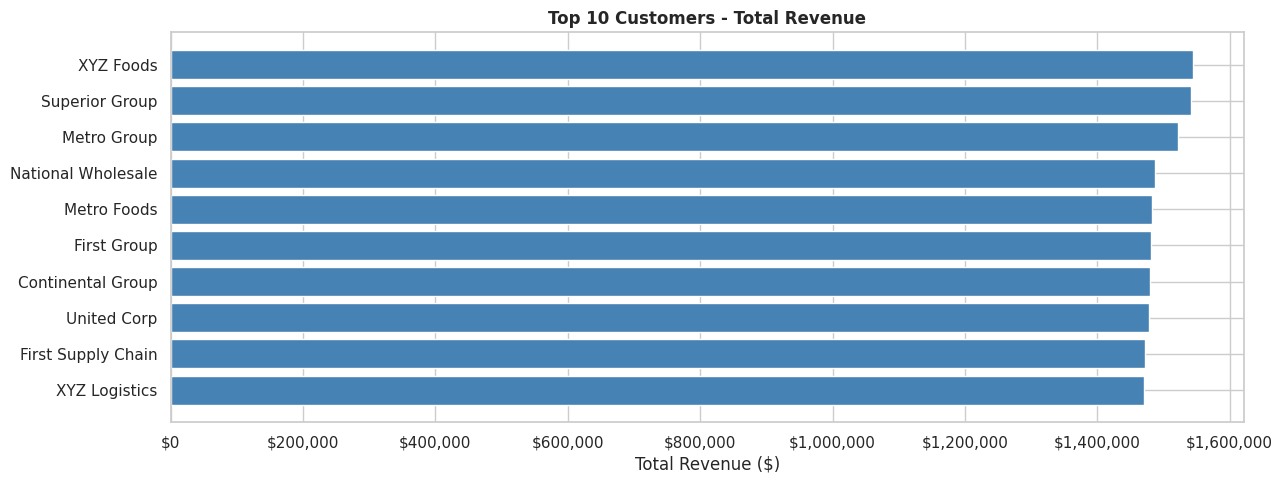

In [10]:
# CELL 10 - Top 10 Customers by Revenue
df_cust = fetch("customer_revenue")
df_cust["total_revenue"] = pd.to_numeric(df_cust["total_revenue"], errors="coerce")
print("Top 10 Customers by Revenue")
print(df_cust.to_string(index=False))

plt.figure(figsize=(13, 5))
plt.barh(df_cust["customer_name"][::-1], df_cust["total_revenue"][::-1], color="steelblue")
plt.title("Top 10 Customers - Total Revenue", fontweight="bold")
plt.xlabel("Total Revenue ($)")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

In [11]:
# CELL 11 - At-Risk Customers (no loads in 90+ days)
df_risk = fetch("customer_atrisk")
df_risk["annual_revenue_potential"] = pd.to_numeric(df_risk["annual_revenue_potential"], errors="coerce")
print(f"At-risk customers: {len(df_risk)}")
print(f"Revenue potential at risk: ${float(df_risk['annual_revenue_potential'].sum()):,.0f}")
print()
print(df_risk.to_string(index=False))

At-risk customers: 15
Revenue potential at risk: $73,278,298

            customer_name customer_type  annual_revenue_potential last_load_date  days_inactive
      First Manufacturing          Spot                   4990599     2024-12-29            432
           Superior Group     Dedicated                   4983476     2024-12-26            435
          National Retail      Contract                   4936566     2024-12-31            430
                ABC Group          Spot                   4931991     2024-12-25            436
     Global Manufacturing      Contract                   4925587     2024-12-26            435
       Elite Supply Chain          Spot                   4895027     2024-12-31            430
                 ABC Corp          Spot                   4893591     2024-12-31            430
         First Industries     Dedicated                   4892669     2024-12-31            430
               Metro Corp      Contract                   4887111     2024

---
## Section 7 - Safety Incidents

     incident_type  total  preventable  injuries  total_claims  avg_claim
     DOT Violation     39           18         5    581,447.22  14,908.90
          Accident     35           14         4    487,418.14  13,926.23
  Equipment Damage     35            9        10    740,970.73  21,170.59
Customer Complaint     34           13        10    432,491.94  12,720.35
  Moving Violation     27           10         4    410,843.79  15,216.44


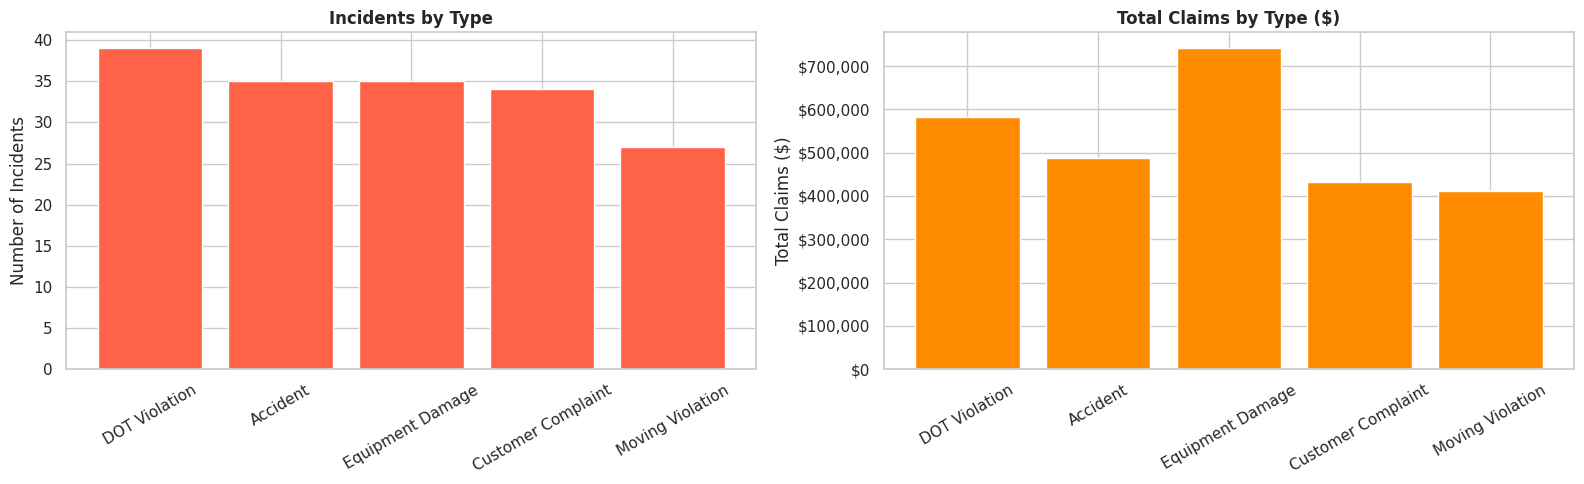

In [12]:
# CELL 12 - Safety Incidents by Type
df_saf = fetch("safety_by_type")
for col in ["total","total_claims"]:
    df_saf[col] = pd.to_numeric(df_saf[col], errors="coerce")
print(df_saf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(df_saf["incident_type"], df_saf["total"], color="tomato")
axes[0].set_title("Incidents by Type", fontweight="bold")
axes[0].set_ylabel("Number of Incidents")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(df_saf["incident_type"], df_saf["total_claims"], color="darkorange")
axes[1].set_title("Total Claims by Type ($)", fontweight="bold")
axes[1].set_ylabel("Total Claims ($)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

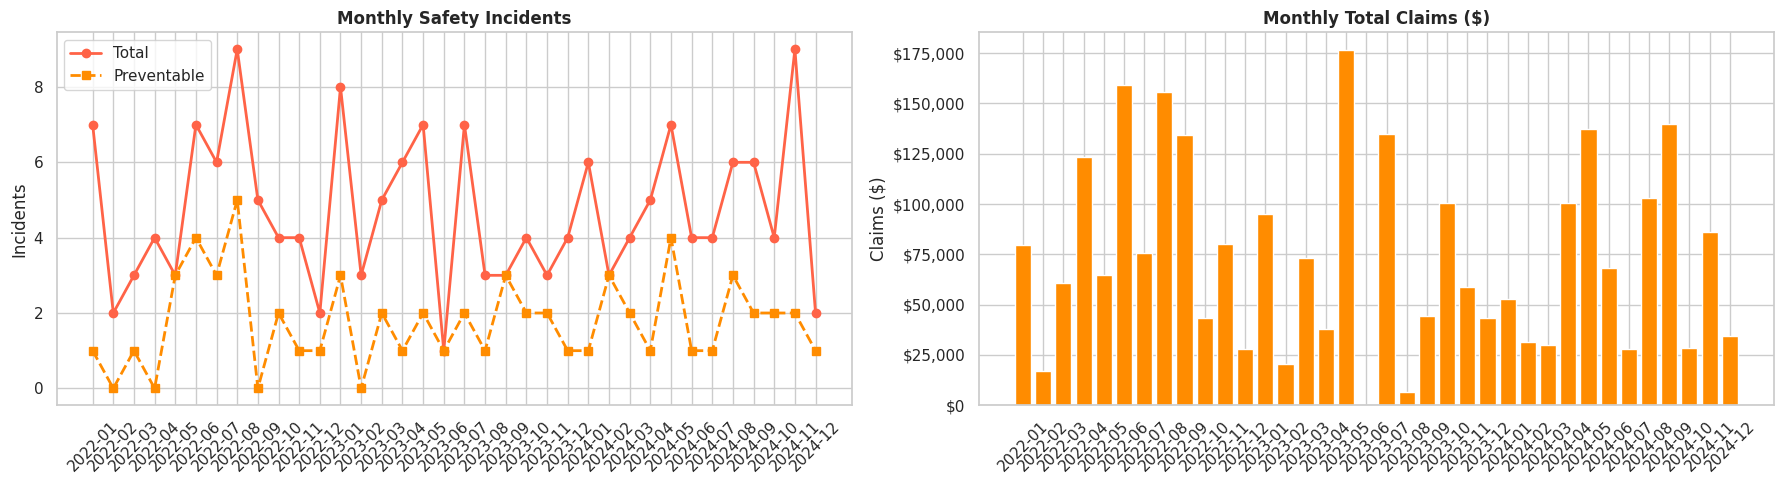

In [13]:
# CELL 13 - Monthly Safety Trend
df_trend = fetch("safety_monthly")
for col in ["incidents","preventable","total_claims"]:
    df_trend[col] = pd.to_numeric(df_trend[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(df_trend["month"], df_trend["incidents"],
             marker="o", color="tomato", linewidth=2, label="Total")
axes[0].plot(df_trend["month"], df_trend["preventable"],
             marker="s", color="darkorange", linewidth=2, linestyle="--", label="Preventable")
axes[0].set_title("Monthly Safety Incidents", fontweight="bold")
axes[0].set_ylabel("Incidents")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[1].bar(df_trend["month"], df_trend["total_claims"], color="darkorange")
axes[1].set_title("Monthly Total Claims ($)", fontweight="bold")
axes[1].set_ylabel("Claims ($)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

---
## Complete!

| Section | Recommended Action |
|---------|--------------------|
| Driver Performance | Coach low on-time drivers; reward top earners |
| Route Profitability | Renegotiate bottom 10 rate/mile lanes |
| Fleet Utilization | Investigate trucks with high downtime |
| Fuel Efficiency | Train below-average MPG drivers |
| Customer Revenue | Re-engage at-risk accounts |
| Safety | Reduce preventable incidents to cut claim costs |